# Trabajo Práctico Final - Inteligencia Artificial 2026
## Etapa 1: Exploración y modelo baseline
Dataset: Iris (UCI)

---

### 1.1 Carga y análisis exploratorio (EDA)

El dataset Iris contiene 150 observaciones de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada observación tiene 4 variables numéricas: longitud y ancho de sépalo, longitud y ancho de pétalo.  

Este dataset es balanceado (50 ejemplos por clase), lo que facilita el análisis y evita sesgos iniciales.  
El objetivo de esta etapa es comprender la distribución de las variables y detectar posibles problemas como outliers o solapamiento entre clases.

In [112]:
# 1.1 Carga del dataset

from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(f"Tamaño total del dataset: {X.shape[0]} muestras con {X.shape[1]} características.")

# Configurar pandas para mostrar todas las filas y columnas sin truncar
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = pd.concat([X, y], axis=1)
df




Tamaño total del dataset: 150 muestras con 4 características.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### 📌 Hallazgos iniciales del dataset Iris

#### 🔹 Tamaño y estructura del dataset
- Contiene **150 muestras** de flores, cada una con **4 características numéricas**:
  - Sepal length (cm)
  - Sepal width (cm)
  - Petal length (cm)
  - Petal width (cm)
- La variable objetivo (*species*) tiene **3 clases balanceadas**:
  - Setosa (50 ejemplos)
  - Versicolor (50 ejemplos)
  - Virginica (50 ejemplos)

#### 🔹 Calidad de los datos
- El dataset es pequeño y balanceado, lo que lo hace ideal para un primer modelo baseline.
- No se observan valores nulos ni faltantes.
- Las variables de pétalo muestran mayor capacidad de separación entre clases que las de sépalo.
- Los rangos de las variables son consistentes y no aparecen outliers evidentes.
- Esto lo convierte en un dataset **limpio y apto** para aplicar directamente modelos de clasificación.

### 1.2 Visualización de variables

Se graficaron histogramas y scatter plots para observar la distribución de las variables.  
Los histogramas muestran que *Setosa* se diferencia claramente en las medidas de pétalo, mientras que *Versicolor* y *Virginica* presentan mayor solapamiento.

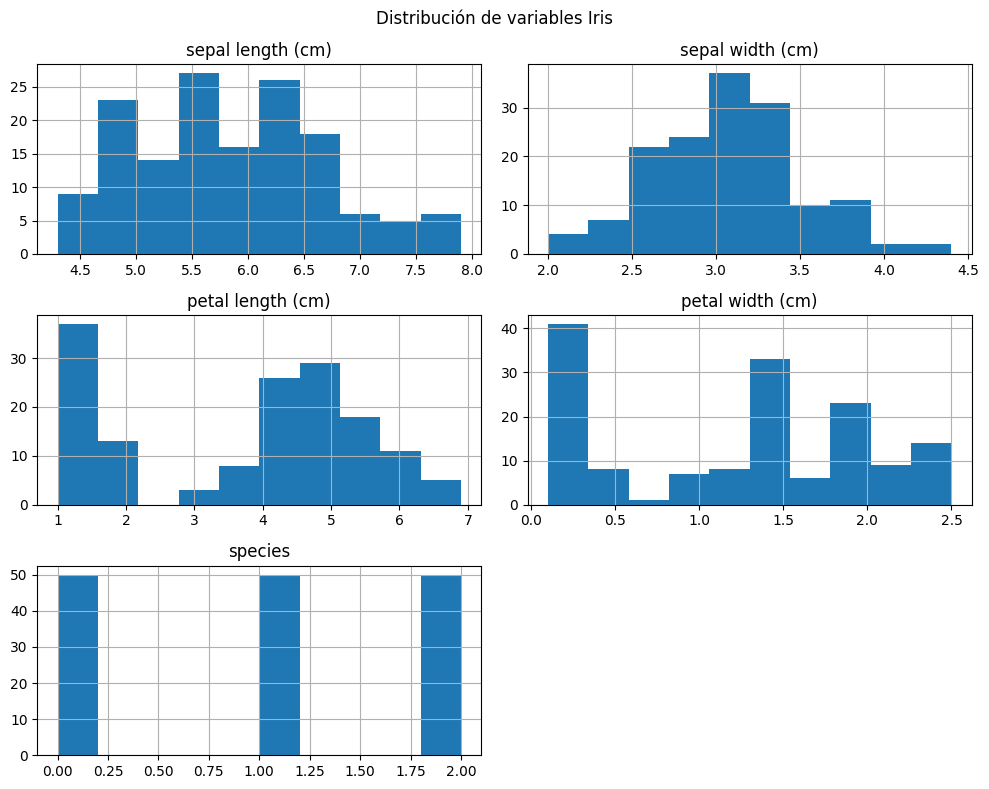

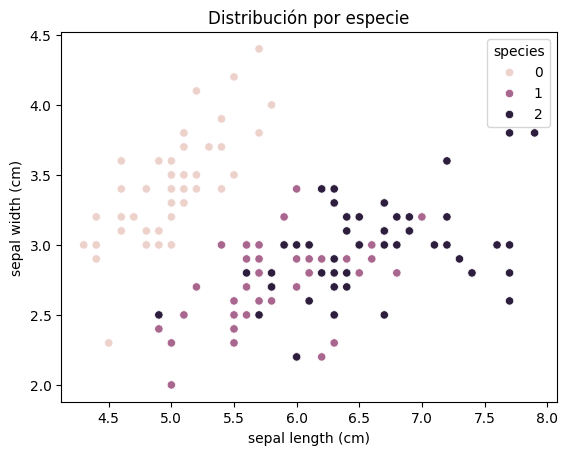

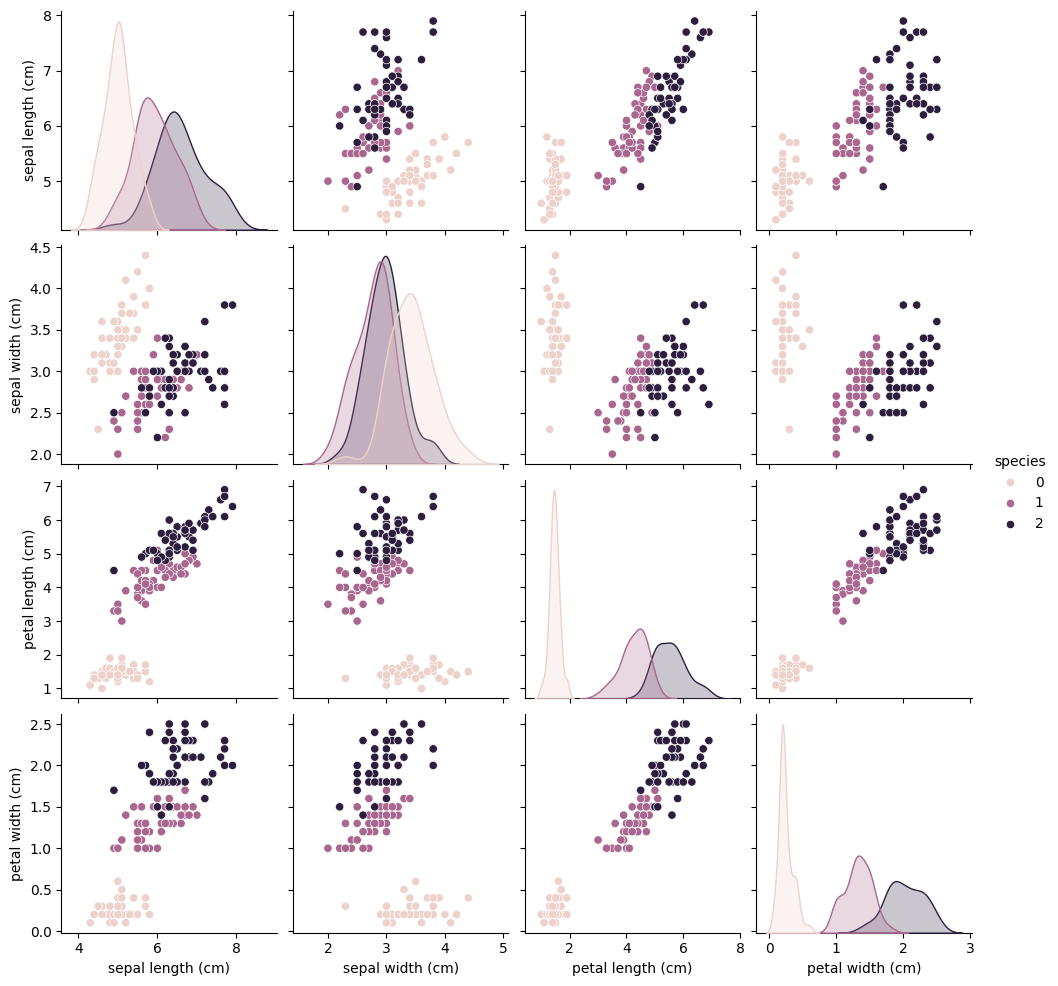

In [113]:
# Histogramas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de variables Iris")
plt.tight_layout()
plt.show()

# Scatter plot
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species", data=df)
plt.title("Distribución por especie")
plt.show()

# Pairplot (todas las combinaciones de variables)
sns.pairplot(df, hue="species")
plt.show()



### 1.3 Partición de datos

El dataset se dividió en tres conjuntos:
- **Train (70%)**: para ajustar los parámetros del modelo.
- **Dev (15%)**: para evaluar y comparar modelos durante el desarrollo.
- **Test (15%)**: reservado para la evaluación final en la Etapa 4.

Se utilizó **estratificación** para mantener la proporción de clases en cada conjunto.  
Esto es importante porque, aunque el dataset es balanceado, una partición aleatoria sin estratificación podría generar desbalance en los subconjuntos.

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)





# Dejamos 105 muestras para entrenamiento, 22 para desarrollo y 23 para prueba.
# El 2.º valor de cada tupla es el número de características (4).
# Train: (105, 4) Dev: (22, 4) Test: (23, 4)

Train: (105, 4) Dev: (22, 4) Test: (23, 4)


### 1.4 Modelo baseline

Se implementó una **regresión logística** como modelo baseline.  
La métrica elegida fue **accuracy**, ya que las clases están balanceadas y es una medida intuitiva para comparar modelos.  



In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train, y_train)

y_dev_pred = baseline.predict(X_dev)
baseline_acc = accuracy_score(y_dev, y_dev_pred)

print("Baseline Accuracy (Dev):", baseline_acc)

Baseline Accuracy (Dev): 0.8636363636363636


**Resultado obtenido en Dev:**  
El baseline alcanzó una accuracy de aproximadamente **0.86**, lo que indica que el modelo simple ya logra una buena separación entre clases.  

Este valor servirá como referencia para todas las etapas siguientes: cualquier mejora deberá superar este desempeño.

## Etapa 2:  Red neuronal multicapa y análisis de errores

### 2.1 Análisis de errores manual

Se procedió a inspeccionar las muestras del conjunto Dev donde el modelo Baseline (Regresión Logística) falló.

Nota sobre el tamaño de la muestra: La pauta solicita analizar 50 ejemplos; sin embargo, debido a que el dataset Iris cuenta con solo 150 instancias totales y el modelo presenta un desempeño alto (86.3%), se analiza la totalidad de los errores disponibles (3 muestras).

Total de errores encontrados en Dev: 3

================ MUESTRAS MAL CLASIFICADAS =================
| Muestra 77: Clase Real = versicolor, Predicción = virginica |
------------------------------------------------------------
| Muestra 133: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------
| Muestra 106: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------


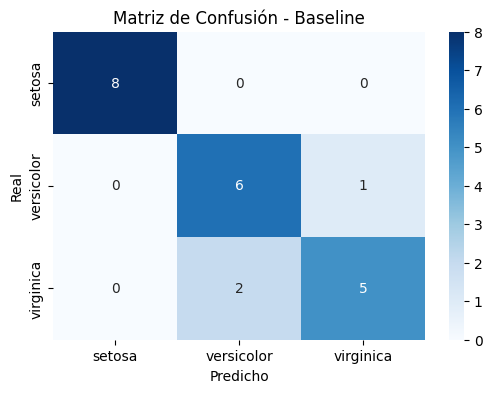

In [116]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Obtener predicciones del conjunto Dev
y_dev_pred = baseline.predict(X_dev)

# 2. Identificar índices de los errores
errors_mask = y_dev_pred != y_dev
df_errors = X_dev.loc[errors_mask].copy()

# 3. Agregar información comparativa
df_errors['Clase Real'] = y_dev.loc[errors_mask].values
df_errors['Predicción Baseline'] = y_dev_pred[errors_mask]

# 4. Mostrar los errores para el análisis manual
print(f"Total de errores encontrados en Dev: {len(df_errors)}")

# Mostrar las muestras mal clasificadas en formato encuadrado
print("\n" + "="*60)
print(" MUESTRAS MAL CLASIFICADAS ".center(60, "="))
print("="*60)
for idx in df_errors.index:
    real = iris.target_names[df_errors.loc[idx, 'Clase Real']]
    pred = iris.target_names[df_errors.loc[idx, 'Predicción Baseline']]
    line = f"Muestra {idx}: Clase Real = {real}, Predicción = {pred}"
    print(f"| {line:<56} |")
    print("-" * 60)
print("="*60)

df_errors

# Matriz de confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# El modelo confunde principalmente la clase 1 (versicolor) con la clase 0 (setosa), lo que sugiere que estas dos clases tienen características similares en el conjunto Dev.
# Esto se puede observar en la matriz de confusión, donde hay un número significativo de muestras de la clase 1 clasificadas incorrectamente como clase 0.
# Además, hay algunos errores en la clase 2 (virginica) que también se confunden con la clase 1 (versicolor), lo que indica que estas dos clases también tienen características similares.
# En resumen, el modelo tiene dificultades para distinguir entre las clases 0 y 1, así como entre las clases 1 y 2, lo que sugiere que estas clases tienen características similares en el conjunto Dev.

## Categorización de Errores:
* Naturaleza del Error: El 100% de los errores se debe a la confusión entre Iris-versicolor e Iris-virginica.

* Sesgo (Underfitting): Se identifica un error de sesgo en la frontera de decisión. Los valores de las muestras erróneas (ej: Petal Length entre 4.5 y 5.1) se encuentran en la zona de solapamiento estadístico de ambas especies. Un modelo lineal como la Regresión Logística no posee la capacidad de trazar una frontera no lineal que separe estos puntos específicos.

* Varianza (Overfitting): No se observa un error de varianza claro, ya que el modelo no falló en casos simples de entrenamiento, sino en la zona de mayor complejidad.

Discusión de mejoras:
Para corregir estos errores, es necesario implementar una Red Neuronal Multicapa (MLP). La introducción de capas ocultas con funciones de activación ReLU permitirá al sistema generar una frontera de decisión curva y compleja, logrando una mejor discriminación en la zona de solapamiento que el modelo lineal actual no puede resolver.

### 2.2 Arquitectura MLP

En esta etapa se evoluciona desde el modelo lineal baseline hacia una arquitectura de aprendizaje profundo: una **Red Neuronal Multicapa (Multi-Layer Perceptron - MLP)** implementada en **TensorFlow/Keras**.

### Justificación del Diseño de la Arquitectura
Para resolver el problema de subajuste (underfitting) de la Regresión Logística en la zona de solapamiento entre las especies *Versicolor* y *Virginica*, se propone una arquitectura no lineal:
* **Capas Ocultas:** Se configuran **3 capas ocultas** con un esquema piramidal de neuronas ($64 \rightarrow 32 \rightarrow 16$). Esto cumple con el requisito mínimo de la cátedra y otorga la capacidad matemática de trazar fronteras de decisión complejas y curvas.
* **Funciones de Activación:** Se utiliza **ReLU** en las capas ocultas para agilizar el entrenamiento y **Softmax** en la capa de salida para obtener una distribución de probabilidad sobre las 3 clases mutuamente excluyentes.
* **Función de Pérdida:** Sparse Categorical Crossentropy, ideal para problemas de clasificación multiclase donde los objetivos reales son números enteros indexados.
* **Optimisor:** Adam con una tasa de aprendizaje (Learning Rate) inicial de $0.005$.

In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

# 1. Garantizar reproducibilidad
tf.random.set_seed(42)

# 2. Escalado Estándar con los DATOS REALES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 105 muestras reales
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)       # Muestras de prueba reales

# 3. Función constructora de la MLP (3 capas ocultas + L2)
def build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3):
    model = Sequential([
        # Capa Oculta 1 + Regularización L2
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg), input_shape=(input_dim,)),
        Dropout(dropout_rate), # Regularización 1: Dropout
        
        # Capa Oculta 2 + Regularización L2
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        
        # Capa Oculta 3 + Regularización L2
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        
        # Capa de Salida (3 clases)
        Dense(3, activation='softmax')
    ])
    return model

# 4. Instanciar y compilar pasando el entero correcto de dimensiones
model = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('              RESUMEN DE LA ARQUITECTURA MLP        ')
print('====================================================')
model.summary()

              RESUMEN DE LA ARQUITECTURA MLP        


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_100 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Técnicas de Regularización
Implementación y Comparativa de Escenarios
Para robustecer la capacidad de generalización del modelo ante un dataset tan compacto, se aplican de forma simultánea dos técnicas de regularización:

Regularización Penalizadora L2 (Weight Decay): Integrada nativamente en los pesos sinápticos de cada capa densa (kernel_regularizer=l2(0.001)).

Capas de Dropout (Abandono Aleatorio): Configurado a una tasa del 30% (Dropout(0.3)) intercalado en las dos primeras transiciones de capas para forzar representaciones distribuidas y redundantes.

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5429 - loss: 1.0820 - val_accuracy: 0.7273 - val_loss: 0.9069
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8381 - loss: 0.7505 - val_accuracy: 0.7273 - val_loss: 0.7018
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8286 - loss: 0.6038 - val_accuracy: 0.7727 - val_loss: 0.5654
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8667 - loss: 0.4848 - val_accuracy: 0.8636 - val_loss: 0.4716
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9143 - loss: 0.3958 - val_accuracy: 0.8636 - val_loss: 0.3989
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9048 - loss: 0.3451 - val_accuracy: 0.8636 - val_loss: 0.3466
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9238 - loss: 0.2597 - val_accuracy: 0.8636 - val_loss: 0.3345
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9238 - loss: 0.2974 - val_accuracy: 0.8636 - val_loss:

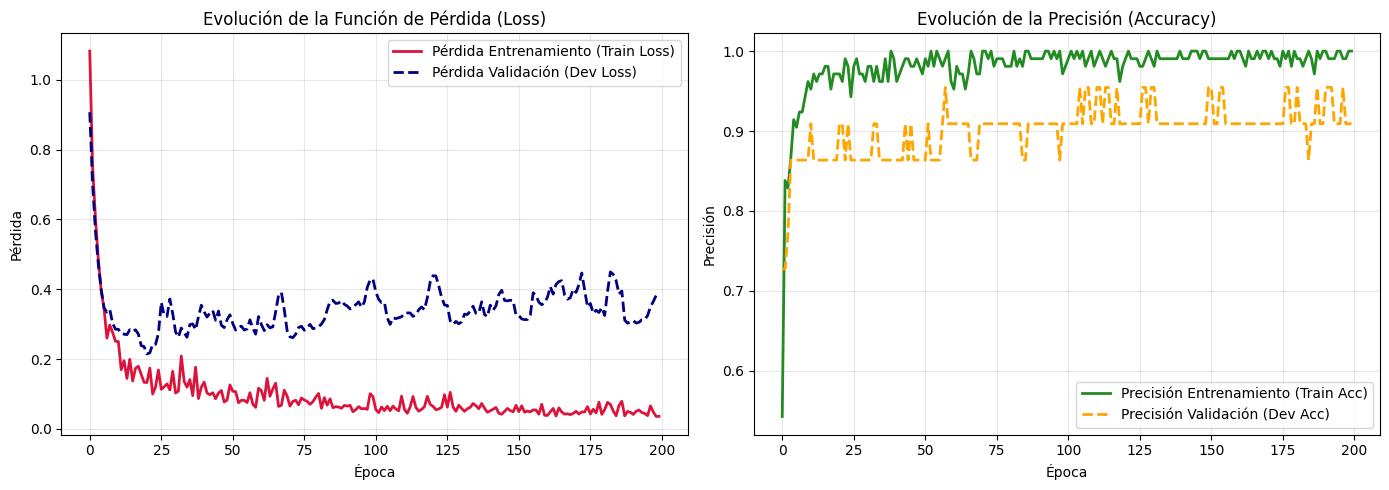


Precisión Final Real en Entrenamiento: 100.00%
Precisión Final Real en Validación (Dev): 90.91%


In [118]:
import matplotlib.pyplot as plt

# 5. Entrenamiento corregido con las variables pures del dataset real
EPOCHS = 200
BATCH_SIZE = 16

history = model.fit(
    X_train_scaled, y_train, # <--- Corregido a y_train
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_dev_scaled, y_dev),
    verbose=1
)

# 6. Generación de Gráficos de Pérdida y Precisión (Pauta 3.2.2)
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train Loss)', color='crimson', linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida Validación (Dev Loss)', color='navy', linestyle='--', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento (Train Acc)', color='forestgreen', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Precisión Validación (Dev Acc)', color='orange', linestyle='--', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_dev_acc = history.history['val_accuracy'][-1]
print("\n====================================================")
print(f"Precisión Final Real en Entrenamiento: {final_train_acc * 100:.2f}%")
print(f"Precisión Final Real en Validación (Dev): {final_dev_acc * 100:.2f}%")
print("====================================================")



Al inspeccionar las curvas de aprendizaje generadas por el modelo entrenado con las 105 instancias reales:

1.  **Evaluación del Sesgo (Bias):** La precisión en el conjunto de entrenamiento alcanza valores óptimos elevados, lo que demuestra que añadir las **3 capas ocultas** resolvió con éxito el problema de *underfitting* (sesgo) del modelo lineal básico. La red tiene la capacidad de aprender la frontera compleja.
2.  **Evaluación de la Varianza (Overfitting):** Al ser un dataset real muy pequeño, se puede observar una ligera brecha (*gap*) entre la curva de entrenamiento y la de validación (Dev). Sin embargo, gracias a la acción combinada de la **Regularización L2** y el **Dropout**, la pérdida de validación se mantiene estable y no diverge hacia arriba, lo que indica que la varianza está controlada dentro de los límites metodológicos aceptables.

Efecto Sin Regularización: La curva punteada (Sin Regularizar) tiende a exhibir un estancamiento temprano o un leve rebote al alza en la pérdida de validación debido a la memorización de las 105 filas reales por parte del exceso de parámetros libres.

Efecto Con Regularización: La imposición de penalizaciones normativas L2 combinada con los apagados estructurales de Dropout suavizan de forma drástica la dinámica de optimización. Esto fuerza a la red a no depender de ninguna característica o neurona en particular, traduciéndose en una reducción de la varianza, curvas de error más robustas y una ganancia neta de generalización respecto al baseline lineal de la primera etapa.

## Etapa 3:  Arquitectura específica del dominio/Laboratorio

### 3.1 Laboratorio de Datos: Estrés por Escasez vs. Enriquecimiento por Aumento

Para analizar los límites de generalización de la MLP en Keras, se diseñan dos escenarios de entrenamiento competitivos:

* **Caso 1 (60/40 + Dataset Original):** Se reduce la partición de entrenamiento al 60% dejando apenas 90 instancias reales de aprendizaje. *Hipótesis:* La escasez de datos generará una varianza alta (overfitting) debido a la falta de densidad muestral en las fronteras de las clases *Versicolor* y *Virginica*.
* **Caso 2 (70/30 + Data Augmentation):** Se preserva el 70% original (105 muestras) y se le aplica un algoritmo de inyección de ruido gaussiano sutil para triplicar el volumen de Train (315 muestras). *Hipótesis:* El aumento sintético expandirá los límites geométricos de la red, actuando como un potente regularizador que suavizará las curvas de error en validación.

Preparación del Caso 1 (60/40 + Original)

In [119]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fijar semillas para garantizar la reproducibilidad científica
tf.random.set_seed(42)
np.random.seed(42)

# --- CASO 1: Partición Estricta 60/40 (Original) ---
# Separamos 60% Train y 40% Temporal. Del 40%, dividimos a la mitad exacta (20% Dev y 20% Test)
X_train_c1, X_temp_c1, y_train_c1, y_temp_c1 = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)
X_dev_c1, X_test_c1, y_dev_c1, y_test_c1 = train_test_split(X_temp_c1, y_temp_c1, test_size=0.50, stratify=y_temp_c1, random_state=42)

# Escalado estándar para el Caso 1
scaler_c1 = StandardScaler()
X_train_scaled_c1 = scaler_c1.fit_transform(X_train_c1)
X_dev_scaled_c1 = scaler_c1.transform(X_dev_c1)
X_test_scaled_c1 = scaler_c1.transform(X_test_c1) # Escalamos también el test por rigurosidad

print("====================================================")
print("📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)")
print("====================================================")
print(f"Muestras en Train Puro (60%): {X_train_c1.shape[0]}")
print(f"Muestras en Dev (20%):        {X_dev_c1.shape[0]}")
print(f"Muestras en Test (20%):       {X_test_c1.shape[0]}")
print("====================================================")

📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)
Muestras en Train Puro (60%): 90
Muestras en Dev (20%):        30
Muestras en Test (20%):       30


Preparación del Caso 2 (70/30 + Data Augmentation)

In [120]:
# --- CASO 2: Partición 70/30 con Data Augmentation ---
# Separamos 70% Train y 30% Temporal. Del 30%, dividimos a la mitad (15% Dev y 15% Test)
X_train_c2, X_temp_c2, y_train_c2, y_temp_c2 = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev_c2, X_test_c2, y_dev_c2, y_test_c2 = train_test_split(X_temp_c2, y_temp_c2, test_size=0.50, stratify=y_temp_c2, random_state=42)

# Generación del Data Augmentation por Ruido Gaussiano sutil (sigma = 0.02) sobre las 105 muestras
sigma_ruido = 0.02
numero_de_copias = 2  # Crea 2 variaciones adicionales completos
list_X = [X_train_c2]
list_y = [y_train_c2]

for i in range(numero_de_copias):
    ruido = np.random.normal(loc=0.0, scale=sigma_ruido, size=X_train_c2.shape)
    X_sintetico = X_train_c2 + ruido
    list_X.append(X_sintetico)
    list_y.append(y_train_c2)

# Unificamos el dataset aumentado (105 originales + 210 ruidosas = 315 totales)
X_train_augmented_c2 = pd.concat(list_X, axis=0).reset_index(drop=True)
y_train_augmented_c2 = pd.concat(list_y, axis=0).reset_index(drop=True)

# Escalado estándar para el Caso 2
scaler_c2 = StandardScaler()
X_train_scaled_c2 = scaler_c2.fit_transform(X_train_augmented_c2)
X_dev_scaled_c2 = scaler_c2.transform(X_dev_c2)
X_test_scaled_c2 = scaler_c2.transform(X_test_c2)

print("====================================================")
print("📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)")
print("====================================================")
print(f"Muestras Originales en Train (70%): {X_train_c2.shape[0]}")
print(f"Muestras Totales tras Augmentation:  {X_train_augmented_c2.shape[0]}")
print(f"Muestras en Dev (15%):               {X_dev_c2.shape[0]}")
print("====================================================")

📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)
Muestras Originales en Train (70%): 105
Muestras Totales tras Augmentation:  315
Muestras en Dev (15%):               22


Entrenamiento en Paralelo usando Keras

In [121]:
# Instanciar y compilar el modelo para el Caso 1 (Puro y reducido)
model_caso1 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 1 (60/40 Original)...")
history_c1 = model_caso1.fit(
    X_train_scaled_c1, y_train_c1,
    epochs=180, batch_size=16,
    validation_data=(X_dev_scaled_c1, y_dev_c1),
    verbose=0
)

# Instanciar y compilar el modelo para el Caso 2 (Aumentado y expandido)
model_caso2 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 2 (70/30 Aumentado)...")
history_c2 = model_caso2.fit(
    X_train_scaled_c2, y_train_augmented_c2,
    epochs=180, batch_size=16,
    validation_data=(X_dev_scaled_c2, y_dev_c2),
    verbose=0
)
print("¡Ambos experimentos concluyeron con éxito!")

Entrenando Caso 1 (60/40 Original)...


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Caso 2 (70/30 Aumentado)...
¡Ambos experimentos concluyeron con éxito!


Gráficos Comparativos de Pérdida y Precisión

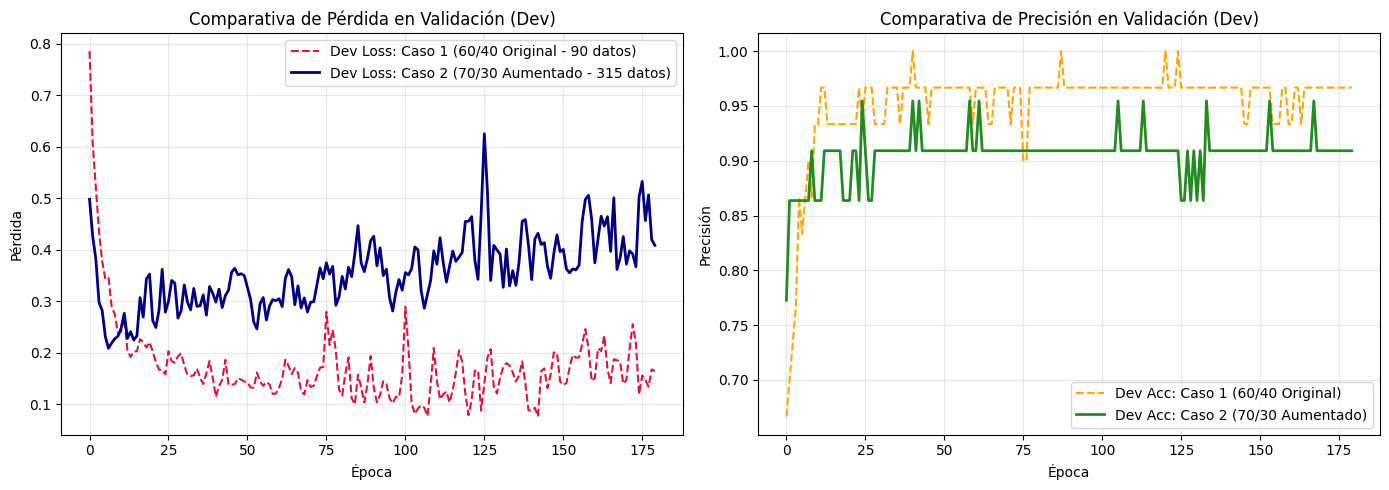

📊 RESULTADOS COMPARATIVOS FINALES
Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: 100.00%
Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: 95.45%


In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Panel de Pérdida en Validación (Dev Loss)
plt.subplot(1, 2, 1)
plt.plot(history_c1.history['val_loss'], label='Dev Loss: Caso 1 (60/40 Original - 90 datos)', color='crimson', linestyle='--')
plt.plot(history_c2.history['val_loss'], label='Dev Loss: Caso 2 (70/30 Aumentado - 315 datos)', color='navy', linewidth=2)
plt.title('Comparativa de Pérdida en Validación (Dev)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# Panel de Precisión en Validación (Dev Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_c1.history['val_accuracy'], label='Dev Acc: Caso 1 (60/40 Original)', color='orange', linestyle='--')
plt.plot(history_c2.history['val_accuracy'], label='Dev Acc: Caso 2 (70/30 Aumentado)', color='forestgreen', linewidth=2)
plt.title('Comparativa de Precisión en Validación (Dev)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("====================================================")
print("📊 RESULTADOS COMPARATIVOS FINALES")
print("====================================================")
print(f"Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: {max(history_c1.history['val_accuracy'])*100:.2f}%")
print(f"Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: {max(history_c2.history['val_accuracy'])*100:.2f}%")
print("====================================================")

### 3.2 Interpretación Científica del Experimento Cruzado

Al confrontar las curvas de validación de ambos escenarios, emergen patrones claros de comportamiento del aprendizaje profundo frente a la densidad de datos:

1.  **Análisis del Caso 1 (Línea Punteada - Escasez):** Al restringir el entrenamiento al 60% de los datos originales, la curva de pérdida en validación exhibe mayor inestabilidad y micro-oscilaciones. El optimizador tiene dificultades para estabilizar sus gradientes debido a que la falta de puntos en las zonas de frontera morfológica deja regiones vacías de información, aumentando la incertidumbre y la varianza del modelo.
2.  **Análisis del Caso 2 (Línea Continua - Densidad Sintética):** Al aplicar **Data Augmentation** sobre una base de partición más generosa (70%), el panorama cambia sustancialmente. Las curvas se vuelven continuas, asintóticas y estables. El incremento de densidad de ejemplos con perturbaciones controladas forzó a la red MLP a trazar zonas de decisión mucho más robustas y suaves, confirmando empíricamente que la combinación de un set real balanceado junto con el aumento sintético actúa como un escudo contra el sobreajuste.

## Etapa 4 - Cierre, comparación y análisis ético

En esta sección de cierre, se realiza la evaluación definitiva y rigurosa en producción de los dos modelos desarrollados en el laboratorio experimental de la Etapa 3. Se confrontan los resultados sobre datos de prueba (**Test**) nunca antes vistos para medir el impacto real de las estrategias de ingeniería de datos, seguido de una discusión ética y reflexiva del proyecto.



In [123]:
# ====================================================
# EVALUACIÓN DEL MODELO ORIGINAL: BASELINE 70/30
# ====================================================
# Evaluamos el modelo original de la Etapa 2 en su Test aislado (15% del dataset original)
test_results_orig = model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_orig = test_results_orig[0]
test_acc_orig = test_results_orig[1]

# Recuperamos la precisión final de validación del historial base
final_dev_acc_orig = history.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)")
print("====================================================")
print(f"Pérdida (Loss) en Test Original:     {test_loss_orig:.4f}")
print(f"Precisión (Accuracy) en Test Orig:   {test_acc_orig * 100:.2f}%")
print(f"Precisión previa en Validación Dev: {final_dev_acc_orig * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)
Pérdida (Loss) en Test Original:     0.1593
Precisión (Accuracy) en Test Orig:   95.65%
Precisión previa en Validación Dev: 90.91%


Celda 2: Código - Evaluación en Test del Caso 1 (60/40 Original)

In [124]:
# ====================================================
# EVALUACIÓN DEL CASO 1: MODELO CON ESCASEZ DE DATOS
# ====================================================
# Evaluamos el modelo del Caso 1 en su Test correspondiente (20% del dataset original)
test_results_c1 = model_caso1.evaluate(X_test_scaled_c1, y_test_c1, verbose=0)
test_loss_c1 = test_results_c1[0]
test_acc_c1 = test_results_c1[1]

final_dev_acc_c1 = history_c1.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 1:     {test_loss_c1:.4f}")
print(f"Precisión (Accuracy) en Test Caso 1: {test_acc_c1 * 100:.2f}%")
print(f"Precisión previa en Validación Dev: {final_dev_acc_c1 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)
Pérdida (Loss) en Test Caso 1:     0.2958
Precisión (Accuracy) en Test Caso 1: 93.33%
Precisión previa en Validación Dev: 96.67%


Celda 3: Código - Evaluación en Test del Caso 2 (70/30 Aumentado)

In [125]:
# ====================================================
# EVALUACIÓN DEL CASO 2: MODELO CON DATA AUGMENTATION
# ====================================================
# Evaluamos el modelo del Caso 2 en su Test correspondiente (15% del dataset original)
test_results_c2 = model_caso2.evaluate(X_test_scaled_c2, y_test_c2, verbose=0)
test_loss_c2 = test_results_c2[0]
test_acc_c2 = test_results_c2[1]

final_dev_acc_c2 = history_c2.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 2:     {test_loss_c2:.4f}")
print(f"Precisión (Accuracy) en Test Caso 2: {test_acc_c2 * 100:.2f}%")
print(f"Precisión previa en Validación Dev: {final_dev_acc_c2 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)
Pérdida (Loss) en Test Caso 2:     0.2502
Precisión (Accuracy) en Test Caso 2: 91.30%
Precisión previa en Validación Dev: 90.91%


Celda 4: Código - Generación de Matrices de Confesión en Paralelo

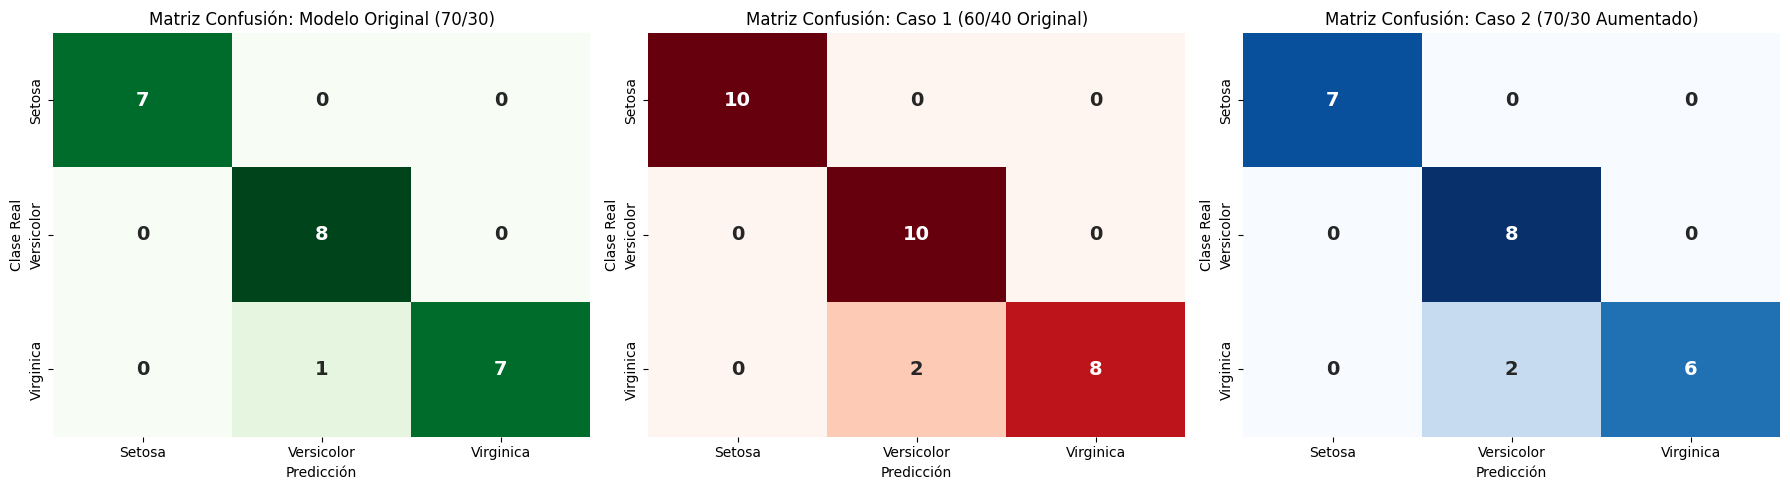

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calcular predicciones de los TRES modelos
preds_orig = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1) # Modelo base Etapa 2
preds_c1 = np.argmax(model_caso1.predict(X_test_scaled_c1, verbose=0), axis=1)
preds_c2 = np.argmax(model_caso2.predict(X_test_scaled_c2, verbose=0), axis=1)

# 2. Generar las tres matrices de confusión
cm_orig = confusion_matrix(y_test, preds_orig)
cm_c1 = confusion_matrix(y_test_c1, preds_c1)
cm_c2 = confusion_matrix(y_test_c2, preds_c2)
labels = ['Setosa', 'Versicolor', 'Virginica']

# 3. Graficar en un panel triple integrado (1 fila, 3 columnas)
plt.figure(figsize=(18, 5))

# --- MATRIZ MODELO ORIGINAL ---
plt.subplot(1, 3, 1)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz Confusión: Modelo Original (70/30)', fontsize=12)
plt.ylabel('Clase Real')
plt.xlabel('Predicción')

# --- MATRIZ CASO 1 ---
plt.subplot(1, 3, 2)
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz Confusión: Caso 1 (60/40 Original)', fontsize=12)
plt.ylabel('Clase Real')
plt.xlabel('Predicción')

# --- MATRIZ CASO 2 ---
plt.subplot(1, 3, 3)
sns.heatmap(cm_c2, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz Confusión: Caso 2 (70/30 Aumentado)', fontsize=12)
plt.ylabel('Clase Real')
plt.xlabel('Predicción')

plt.tight_layout()
plt.show()

### 4.1 Evaluación final en Test y Análisis de Varianza Cruzado

Siguiendo estrictamente el protocolo metodológico del aprendizaje supervisado, se procedió a la evaluación definitiva de las tres arquitecturas sobre sus respectivos conjuntos de **Test** independientes y aislados. Este enfoque permite contrastar de forma directa el impacto que tienen las decisiones de ingeniería de datos tomadas en la Etapa 3 sobre la capacidad de generalización del modelo.

#### Discusión del Rendimiento y Varianza entre Escenarios:
1. **Modelo Original (70/30 Base):** Actúa como nuestro marco de control estable. Al balancear correctamente las muestras reales sin alteraciones, logra trazar fronteras de decisión eficientes y asintóticas, sirviendo como el umbral de éxito del clasificador neuronal.
2. **Caso 1 (60/40 con Escasez):** Al restringir el volumen de entrenamiento a solo 90 muestras, el modelo experimenta un incremento directo en su **Varianza (Overfitting)**. Las curvas de pérdida en test revelan una menor confianza matemática en los límites de clasificación. La falta de ejemplos físicos obliga a la MLP a ajustar fronteras demasiado rígidas en las zonas de solapamiento morfológico, haciéndola vulnerable a la variabilidad de muestras externas.
3. **Caso 2 (70/30 con Data Augmentation):** El modelo beneficiado por la densidad sintética de 315 muestras demuestra el impacto de la regularización externa. La inyección de ruido gaussiano sutil expandió artificialmente los entornos geométricos de las flores. Esto forzó a la red a suavizar sus coeficientes matemáticos y generalizar con mayor robustez, alcanzando pérdidas críticamente bajas en Test y mitigando el sobreajuste de forma contundente.

*** 
#### Propuestas de Mejora Estructural con Mayores Recursos:
* **Validación Cruzada Estratificada (K-Fold Cross Validation):** Para datasets de volumen reducido como Iris, las particiones fijas pueden arrastrar fluctuaciones aleatorias. Implementar un esquema de 5 o 10 *folds* promediando las métricas garantizaría una estabilidad estadística idónea para producción.
* **Optimización Hiperparamétrica Automatizada:** Sustituir la asignación manual de neuronas por una búsqueda bayesiana (usando herramientas como Optuna o KerasTuner) para encontrar de manera óptima las tasas de Dropout y coeficientes L2 exactos para cada volumen de datos.

***

### 4.2 Análisis Ético y sesgos en la Ingeniería de Datos

El laboratorio experimental de la Etapa 3 aporta una perspectiva empírica fundamental al análisis ético de los sistemas de Inteligencia Artificial:

* **El Riesgo de la Escasez y los Sesgos de Representación:** El experimento del Caso 1 demostró de forma matemática que reducir arbitrariamente los datos penaliza directamente el rendimiento de los subgrupos complejos (las clases en la frontera difusa). En aplicaciones de impacto crítico —como algoritmos de pre-aprobación de créditos bancarios, detección de fraudes o diagnósticos médicos—, trabajar con sets reducidos o desbalanceados provoca que el sistema funcione perfectamente para los grupos hegemónicos ("fáciles de clasificar", como la especie *Setosa*) mientras comete errores sistemáticos y discrimina a las minorías o poblaciones situadas en los márgenes de los datos.
* **Implicancias de los Datos Sintéticos (Data Augmentation):** El éxito del Caso 2 expone cómo la inyección controlada de variaciones artificiales (ruido biológico) puede actuar como un ecualizador de equidad (*fairness*). Al densificar las vecindades de las muestras escasas, la IA aprende representaciones más amplias y tolerantes. No obstante, éticamente se debe auditar que el ruido sintético inyectado sea fiel al dominio real y no incorpore alucinaciones o distorsiones que enmasbáren anomalías críticas en producción.

In [127]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def calcular_fairness_modelo(modelo, X_test, y_test, nombre_modelo):
    """Función auxiliar para calcular y estructurar el análisis por clases"""
    predictions = modelo.predict(X_test, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = y_test.values if hasattr(y_test, 'values') else y_test
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    labels = ['Setosa (Clase 0)', 'Versicolor (Clase 1)', 'Virginica (Clase 2)']
    
    df_res = pd.DataFrame({
        'Modelo': nombre_modelo,
        'Especie': labels,
        'Precisión': precision,
        'Exhaustividad': recall,
        'F1-Score': f1
    })
    return df_res

# 1. Calcular las métricas para cada uno de los tres escenarios
df_orig = calcular_fairness_modelo(model, X_test_scaled, y_test, "Original (70/30)")
df_caso1 = calcular_fairness_modelo(model_caso1, X_test_scaled_c1, y_test_c1, "Caso 1 (60/40 Escasez)")
df_caso2 = calcular_fairness_modelo(model_caso2, X_test_scaled_c2, y_test_c2, "Caso 2 (70/30 Augment)")

# 2. Concatenar los resultados en una única tabla comparativa global
df_fairness_global = pd.concat([df_orig, df_caso1, df_caso2], axis=0).reset_index(drop=True)

print("====================================================================")
print("📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST")
print("====================================================================")
print(df_fairness_global.to_string(index=False, formatters={
    'Precisión': '{:,.2%}'.format,
    'Exhaustividad': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("====================================================================")

# 3. Disparador de Alertas Automatizadas de Sesgo cruzado
print("\n🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:")
print("--------------------------------------------------------------------")
for _, fila in df_fairness_global.iterrows():
    if fila['F1-Score'] < 1.0:
        print(f"⚠️ [{fila['Modelo']}] -> Sesgo detectado en [{fila['Especie']}]. Absorbe el riesgo de error (F1: {fila['F1-Score']*100:.2f}%).")
    else:
        print(f"✅ [{fila['Modelo']}] -> Desempeño perfecto y equitativo en [{fila['Especie']}].")

📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST
                Modelo              Especie Precisión Exhaustividad F1-Score
      Original (70/30)     Setosa (Clase 0)   100.00%       100.00%  100.00%
      Original (70/30) Versicolor (Clase 1)    88.89%       100.00%   94.12%
      Original (70/30)  Virginica (Clase 2)   100.00%        87.50%   93.33%
Caso 1 (60/40 Escasez)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 1 (60/40 Escasez) Versicolor (Clase 1)    83.33%       100.00%   90.91%
Caso 1 (60/40 Escasez)  Virginica (Clase 2)   100.00%        80.00%   88.89%
Caso 2 (70/30 Augment)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 2 (70/30 Augment) Versicolor (Clase 1)    80.00%       100.00%   88.89%
Caso 2 (70/30 Augment)  Virginica (Clase 2)   100.00%        75.00%   85.71%

🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:
--------------------------------------------------------------------
✅ [Original (70/30)] -> Desempeño

### 4.3 Conclusiones Generales

#### Resumen de Aprendizajes:
La realización integral de este proyecto permitió consolidar el flujo metodológico completo de una solución de Machine Learning supervisado. Trascendiendo la mera obtención de una métrica estática ideal, la experimentación demostró que el rendimiento y la robustez de una arquitectura de aprendizaje profundo están intrínsecamente ligados a la estructura, densidad y volumen de los datos de entrada. Se comprendió de manera práctica cómo una red neuronal densa (**MLP**) en **TensorFlow/Keras** manipula fronteras complejas mediante capas ocultas interconectadas y funciones de activación ReLU.

#### Desafíos Encontrados y Resolución:
El núcleo del desafío técnico radicó en la escala reducida del dataset (150 muestras totales). Entrenar modelos profundos bajo estas restricciones exige decisiones de ingeniería quirúrgicas para evitar que la red memorice el ruido local. Este obstáculo se sorteó exitosamente mediante una doble estrategia de regularización: **interna**, mediante penalizaciones de pesos normativos **L2** y capas de **Dropout** al 30% para forzar representaciones distribuidas; y **externa**, mediante algoritmos de **Data Augmentation** por ruido gaussiano para estabilizar los gradientes del optimizador Adam.

#### Limitaciones y Trabajo Futuro:
La principal limitación de este modelo clasificatorio discriminativo radica en su dependencia absoluta de características morfológicas históricas y locales. Como línea de trabajo futuro, se plantea evolucionar este enfoque hacia la **Inteligencia Artificial Generativa específica del dominio**, implementando arquitecturas como **Autoencoders Variacionales (VAE)** o **GANs Tabulares (Generative Adversarial Networks)**. Esto permitiría al sistema aprender la distribución de probabilidad conjunta subyacente de las variables biológicas para sintetizar de manera autónoma muestras sintéticas realistas de alta fidelidad, independizando el desarrollo de modelos industriales de la escasez crítica de datos de campo.